In [1]:
# imports
suppressPackageStartupMessages({
    library(data.table)
    library(arrow)
})

# Read and concatenate metadata

In [2]:
meta_files <- list(
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_CTRL-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP2_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_PsD-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-ARBITRATE_assay manifest.csv"
)

get_subset_and_edp <- function(path) {
  fname <- basename(path)
  core <- sub("^Xenium_(.*)_assay manifest\\.csv$", "\\1", fname)
  if (core == "RA-SYN-ARBITRATE") {
      list(subset = "RA-SYN", cohort = "ARBITRATE")
  } else {
      edp <- sub(".*-(EDP[12])$", "\\1", core)
      subset <- sub(paste0("-", edp, "$"), "", core)
      list(subset = subset, cohort = edp)
  }
}

meta_list <- lapply(meta_files, function(f) {
  dt <- fread(f)
  info <- get_subset_and_edp(f)
  dt[, subset := info$subset]
  dt[, cohort := info$cohort]
  dt
})

metadata <- rbindlist(meta_list, use.names = TRUE, fill = TRUE)

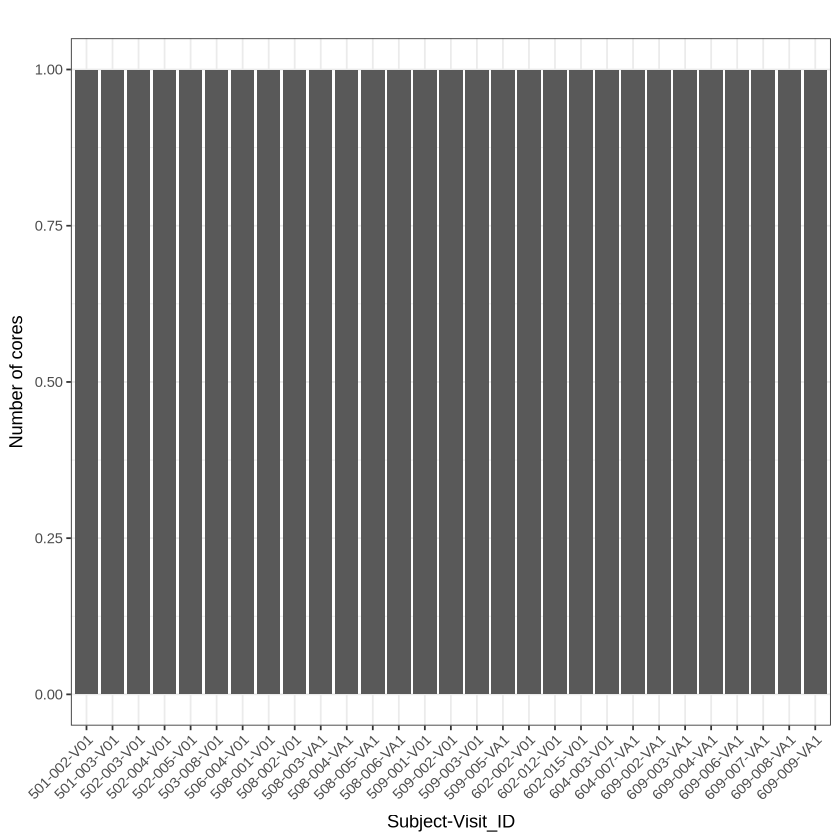

In [3]:
# count rows per Subject-Visit_ID
counts <- metadata[, .N, by = `Subject-Visit_ID`]

# optional: order by count
counts <- counts[order(-N)]

# bar plot
ggplot(counts, aes(x = reorder(`Subject-Visit_ID`, -N), y = N)) +
  geom_bar(stat = "identity") +
  labs(
    x = "Subject-Visit_ID",
    y = "Number of cores",
    title = ""
  ) +
  theme_bw(base_size = 18) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Merge all transcript files for each sample

In [ ]:
sids <- unique(metadata$Sample_ID)
n_sids <- length(sids)
t0 <- Sys.time()

for (sid_i in seq_along(sids)) {
  sid <- sids[[sid_i]]
  t_sample_start <- Sys.time()
  cat(sprintf("[Sample %d/%d] Processing: %s\n", sid_i, n_sids, sid))
  flush.console()

  # find all segmentation.csv files for this sid
  files <- Sys.glob(file.path("out", sid, "baysor_out", "*", "segmentation.csv"))
  if (length(files) == 0) {
    warning(sprintf("No segmentation.csv files found for %s", sid))
    next
  }

  # read and concatenate
  dt_list <- lapply(files, fread)
  dt <- rbindlist(dt_list, fill = TRUE)

  # write parquet
  out_file <- file.path("level3", paste0(sid, ".transcripts.parquet"))
  write_parquet(dt, out_file)

  # Per-sample timing and ETA
  t_sample_end <- Sys.time()
  secs_this_sample <- as.numeric(difftime(t_sample_end, t_sample_start, units = "secs"))
  secs_elapsed_total <- as.numeric(difftime(t_sample_end, t0, units = "secs"))
  secs_per_sample <- secs_elapsed_total / sid_i
  secs_remaining <- secs_per_sample * (n_sids - sid_i)
  cat(sprintf("  -> Done in %.1f sec | avg %.1f sec/sample | est. %.1f sec remaining (%.1f min)\n",
              secs_this_sample, secs_per_sample, secs_remaining, secs_remaining / 60))
  flush.console()
}

[Sample 1/102] Processing: 8073578341-02-02
  -> Done in 20.8 sec | avg 20.8 sec/sample | est. 2105.2 sec remaining (35.1 min)
[Sample 2/102] Processing: 8073579095-02-02
  -> Done in 192.3 sec | avg 106.6 sec/sample | est. 10657.6 sec remaining (177.6 min)
[Sample 3/102] Processing: 8073578234-02-02
  -> Done in 37.3 sec | avg 83.5 sec/sample | est. 8266.5 sec remaining (137.8 min)
[Sample 4/102] Processing: 8073578941-02-02
  -> Done in 71.3 sec | avg 80.5 sec/sample | est. 7884.3 sec remaining (131.4 min)
[Sample 5/102] Processing: 8073578511-02-02
